TensorFlow Version: 2.18.0

--- 1. Loading and Merging Data ---
Initial images found: 40009
Validating images (removing corrupted files)...


  5%|▌         | 2100/40009 [00:13<04:19, 145.84it/s]

Removing corrupted image: /kaggle/input/mura-v11/MURA-v1.1/train/XR_WRIST/patient07840/study1_negative/._image1.png
Removing corrupted image: /kaggle/input/mura-v11/MURA-v1.1/train/XR_WRIST/patient07840/study2_negative/._image2.png
Removing corrupted image: /kaggle/input/mura-v11/MURA-v1.1/train/XR_WRIST/patient07840/study2_negative/._image1.png
Removing corrupted image: /kaggle/input/mura-v11/MURA-v1.1/train/XR_WRIST/patient07840/study2_negative/._image3.png


100%|██████████| 40009/40009 [04:21<00:00, 153.23it/s]


Images after cleaning: 40005 (Removed 4)

--- Splitting Data ---
Training Set:   28003
Validation Set: 4001
Testing Set:    8001

--- 2. Setting up Data Generators ---
Found 28003 validated image filenames belonging to 2 classes.
Found 4001 validated image filenames belonging to 2 classes.
Found 8001 validated image filenames belonging to 2 classes.

--- 3. Building MobileNetV2 Model ---

--- 4. Training ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 458s 480ms/step - accuracy: 0.6816 - loss: 0.6158 - val_accuracy: 0.6726 - val_loss: 0.9844
Epoch 2/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 403s 460ms/step - accuracy: 0.7800 - loss: 0.4817 - val_accuracy: 0.7721 - val_loss: 0.5328
Epoch 3/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 407s 465ms/step - accuracy: 0.8050 - loss: 0.4461 - val_accuracy: 0.7653 - val_loss: 0.5037
Epoch 4/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 406s 464ms/step - accuracy: 0.8073 - loss: 0.4287 - val_accuracy: 0.7921 - val_loss: 0.4656
Epoch 5/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 398s 454ms/step - accuracy: 0.8195 - loss: 0.4100 - val_accuracy: 0.7836 - val_loss: 0.4872
Epoch 6/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 398s 454ms/step - accuracy: 0.8227 - loss: 0.4040 - val_accuracy: 0.7836 - val_loss: 0.4969
Epoch 7/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 394s 450ms/step - accuracy: 0.8345 - loss: 0.3804 - val_accuracy: 0.7868 - val_loss: 0.4907
Epoch 8/25
876/876 ━━━━━━━━━━━━━━━━━━━━ 391s 446ms/step - accuracy: 0.8432 -

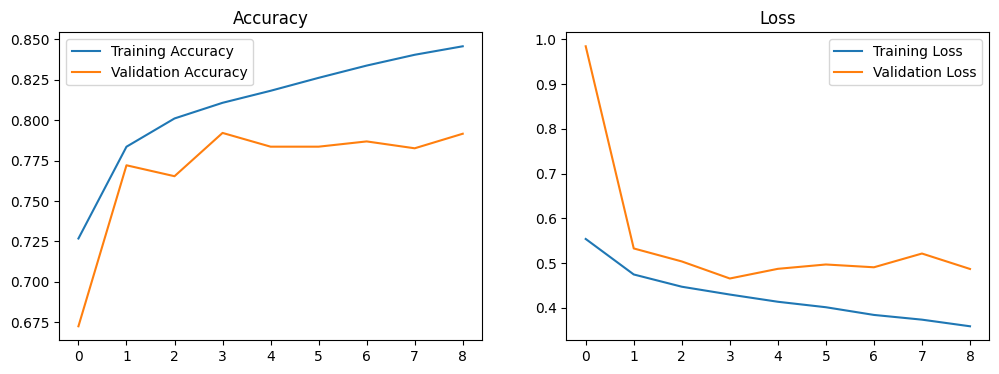

Generating predictions...
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 157ms/step
              precision    recall  f1-score   support

      Normal       0.80      0.87      0.84      4720
    Abnormal       0.79      0.69      0.74      3281

    accuracy                           0.80      8001
   macro avg       0.80      0.78      0.79      8001
weighted avg       0.80      0.80      0.80      8001



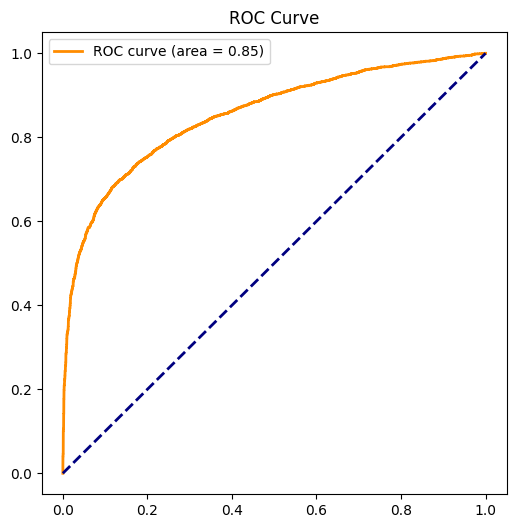

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image, UnidentifiedImageError # Added for validation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tqdm import tqdm # Progress bar

# --- CONFIGURATION ---
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 25
LEARNING_RATE = 1e-4
DATASET_ROOT = '/kaggle/input/mura-v11/MURA-v1.1'

print(f"TensorFlow Version: {tf.__version__}")

# ==========================================
# 1. DATA PREPARATION & CLEANING
# ==========================================
print("\n--- 1. Loading and Merging Data ---")

def create_combined_dataframe(base_path):
    filepaths = []
    labels = []
    
    folders_to_scan = ['train', 'valid']
    
    for folder in folders_to_scan:
        folder_path = os.path.join(base_path, folder)
        if not os.path.exists(folder_path):
            continue
            
        for root, dirs, files in os.walk(folder_path):
            for file in files:
                if file.lower().endswith(('png', 'jpg', 'jpeg')):
                    full_path = os.path.join(root, file)
                    filepaths.append(full_path)
                    
                    if 'positive' in root:
                        labels.append('1') 
                    else:
                        labels.append('0') 

    df = pd.DataFrame({'filepath': filepaths, 'label': labels})
    return df

# Create initial dataframe
full_df = create_combined_dataframe(DATASET_ROOT)
print(f"Initial images found: {len(full_df)}")

# --- CRITICAL STEP: REMOVE BAD IMAGES ---
print("Validating images (removing corrupted files)...")
valid_indices = []

# We loop through all images to check if PIL can open them
for idx, row in tqdm(full_df.iterrows(), total=full_df.shape[0]):
    try:
        # We don't load the whole image, just verify headers to be fast
        with Image.open(row['filepath']) as img:
            img.verify() 
        valid_indices.append(idx)
    except (UnidentifiedImageError, OSError):
        print(f"Removing corrupted image: {row['filepath']}")

# Filter the dataframe to keep only valid images
clean_df = full_df.loc[valid_indices].reset_index(drop=True)
print(f"Images after cleaning: {len(clean_df)} (Removed {len(full_df) - len(clean_df)})")

if len(clean_df) == 0:
    raise ValueError("No valid images found! Check path or dataset integrity.")

# --- SPLITTING ---
print("\n--- Splitting Data ---")
train_val_df, test_df = train_test_split(clean_df, test_size=0.20, stratify=clean_df['label'], random_state=42)
train_df, valid_df = train_test_split(train_val_df, test_size=0.125, stratify=train_val_df['label'], random_state=42)

print(f"Training Set:   {len(train_df)}")
print(f"Validation Set: {len(valid_df)}")
print(f"Testing Set:    {len(test_df)}")

# ==========================================
# 2. DATA GENERATORS
# ==========================================
print("\n--- 2. Setting up Data Generators ---")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

valid_gen = val_test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ==========================================
# 3. MODEL BUILDING (MobileNetV2)
# ==========================================
print("\n--- 3. Building MobileNetV2 Model ---")

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# ==========================================
# 4. TRAINING
# ==========================================
print("\n--- 4. Training ---")

callbacks = [
    ModelCheckpoint('best_mobilenet_mura.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss', mode='min')
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1
)

# ==========================================
# 5. EVALUATION
# ==========================================
print("\n--- 5. Evaluation ---")

# Plotting
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# Classification Report
print("Generating predictions...")
test_gen.reset()
preds = model.predict(test_gen, verbose=1)
y_pred = (preds > 0.5).astype(int).ravel()
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=['Normal', 'Abnormal']))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [10]:
# Save the final trained model
model.save('MURA_MobileNetV2.h5')

print("Model saved successfully as MURA_MobileNetV2.h5")

Model saved successfully as MURA_MobileNetV2.h5
